# **Loan Prediction Dataset**

In [0]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# %pip ile SMOTE'u yükle
%pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Warningleri kapatmak profesyonel görünür
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# 2. Load Data: 
df = pd.read_csv('loans_modified.csv')

**Step_01:** Data Understanding

First, I'll load the dataset and examine the structure using info() and describe(). I see we have a mix of numerical and categorical features.

Observation: I notice Loan_ID is just an identifier, so I will remove it as it has no predictive power. Also, Credit_History seems to be a float but it's actually a categorical flag (1 or 0).

In [0]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             534 non-null    object 
 1   gender              534 non-null    object 
 2   married             544 non-null    object 
 3   dependents          531 non-null    object 
 4   education           541 non-null    object 
 5   self_employed       529 non-null    object 
 6   applicant_income    537 non-null    float64
 7   coapplicant_income  529 non-null    float64
 8   loan_amount         533 non-null    float64
 9   loan_amount_term    535 non-null    float64
 10  credit_history      541 non-null    float64
 11  property_area       542 non-null    object 
 12  loan_status         535 non-null    float64
dtypes: float64(6), object(7)
memory usage: 57.3+ KB


,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,loan_status
count,537.000000,529.000000,533.000000,535.000000,541.000000,535.000000
mean,5379.370577,1692.604764,147.433396,341.674766,0.878004,0.717757
std,6064.809533,3093.379309,85.851735,65.301425,0.327584,0.450512
min,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000
25%,2894.000000,0.000000,100.000000,360.000000,1.000000,0.000000
50%,3762.000000,1250.000000,128.000000,360.000000,1.000000,1.000000
75%,5818.000000,2333.000000,172.000000,360.000000,1.000000,1.000000
max,81000.000000,41667.000000,650.000000,480.000000,1.000000,1.000000


**Step_02:** Data Cleaning

I see some missing values. For categorical variables like Gender or Self_Employed, I will impute them with the mode (most frequent value).

For LoanAmount, I prefer using the median instead of the mean because financial data often has outliers (skewed distributions) which can distort the mean.

CV Bağlantısı: In my previous analysis projects, handling data quality early on was crucial for building reliable models.

In [0]:
# 1. Drop Loan_ID
df.drop('loan_id', axis=1, inplace=True)

# 2. Check Nulls
print(df.isnull().sum())

# 3. Handle 'Dependents' (Eğer '3+' varsa düzeltme)
# df['dependents'] = df['dependents'].replace('3+', 3).astype(int) 
# Not: Eğer veri temizse bu adımı atla, ama kontrol etmek 'Senior' bakış açısıdır.

# 4. Fill Missing Values
# Categorical -> Mode (En sık geçen)
for col in ['gender', 'married', 'dependents', 'self_employed', 'credit_history']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical -> Median (Outlier'lardan etkilenmemek için)
df['loan_amount'].fillna(df['loan_amount'].median(), inplace=True)
df['loan_amount_term'].fillna(df['loan_amount_term'].mode()[0], inplace=True) # Term genelde standarttır (360 ay)

gender                29
married               19
dependents            32
education             22
self_employed         34
applicant_income      26
coapplicant_income    34
loan_amount           30
loan_amount_term      28
credit_history        22
property_area         21
loan_status           28
dtype: int64


- 28 tane satırda kredi durumu (Onay/Red) belli değil. Hedef değişkeni olmayan veriyi modelleyemeyiz, bunları silmeliyiz.

In [0]:
# Final Polish:

# 1. Eksik kalan kategorik verileri de 'Mode' ile dolduralım
remaining_cat_cols = ['education', 'property_area']
for col in remaining_cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 2. Gelir bilgilerindeki (Income) boşlukları 'Median' ile dolduralım
df['applicant_income'].fillna(df['applicant_income'].median(), inplace=True)
df['coapplicant_income'].fillna(df['coapplicant_income'].median(), inplace=True)

# 3. KRİTİK ADIM: Hedef değişkeni (Loan Status) boş olan satırları siliyoruz
df.dropna(subset=['loan_status'], inplace=True)

# 4. Kontrol (Hepsi 0 olmalı)
print("✅ Kalan eksik veri sayısı:")
print(df.isnull().sum().sum())

✅ Kalan eksik veri sayısı:
0


**Step_03:** EDA

Looking at the Credit_History vs Loan_Status plot, there is a very strong correlation. Applicants with a credit history of 1 are significantly more likely to get approved. This aligns with financial domain knowledge.


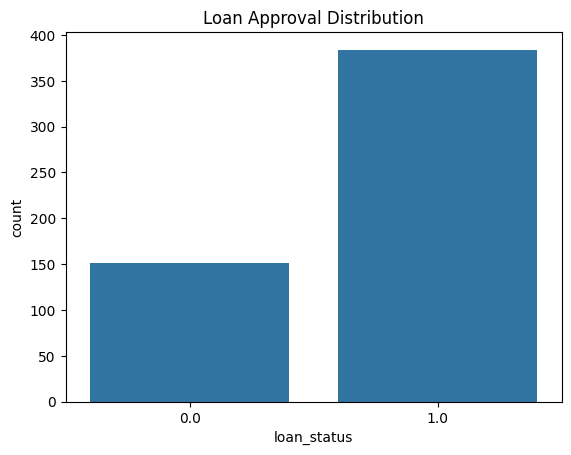

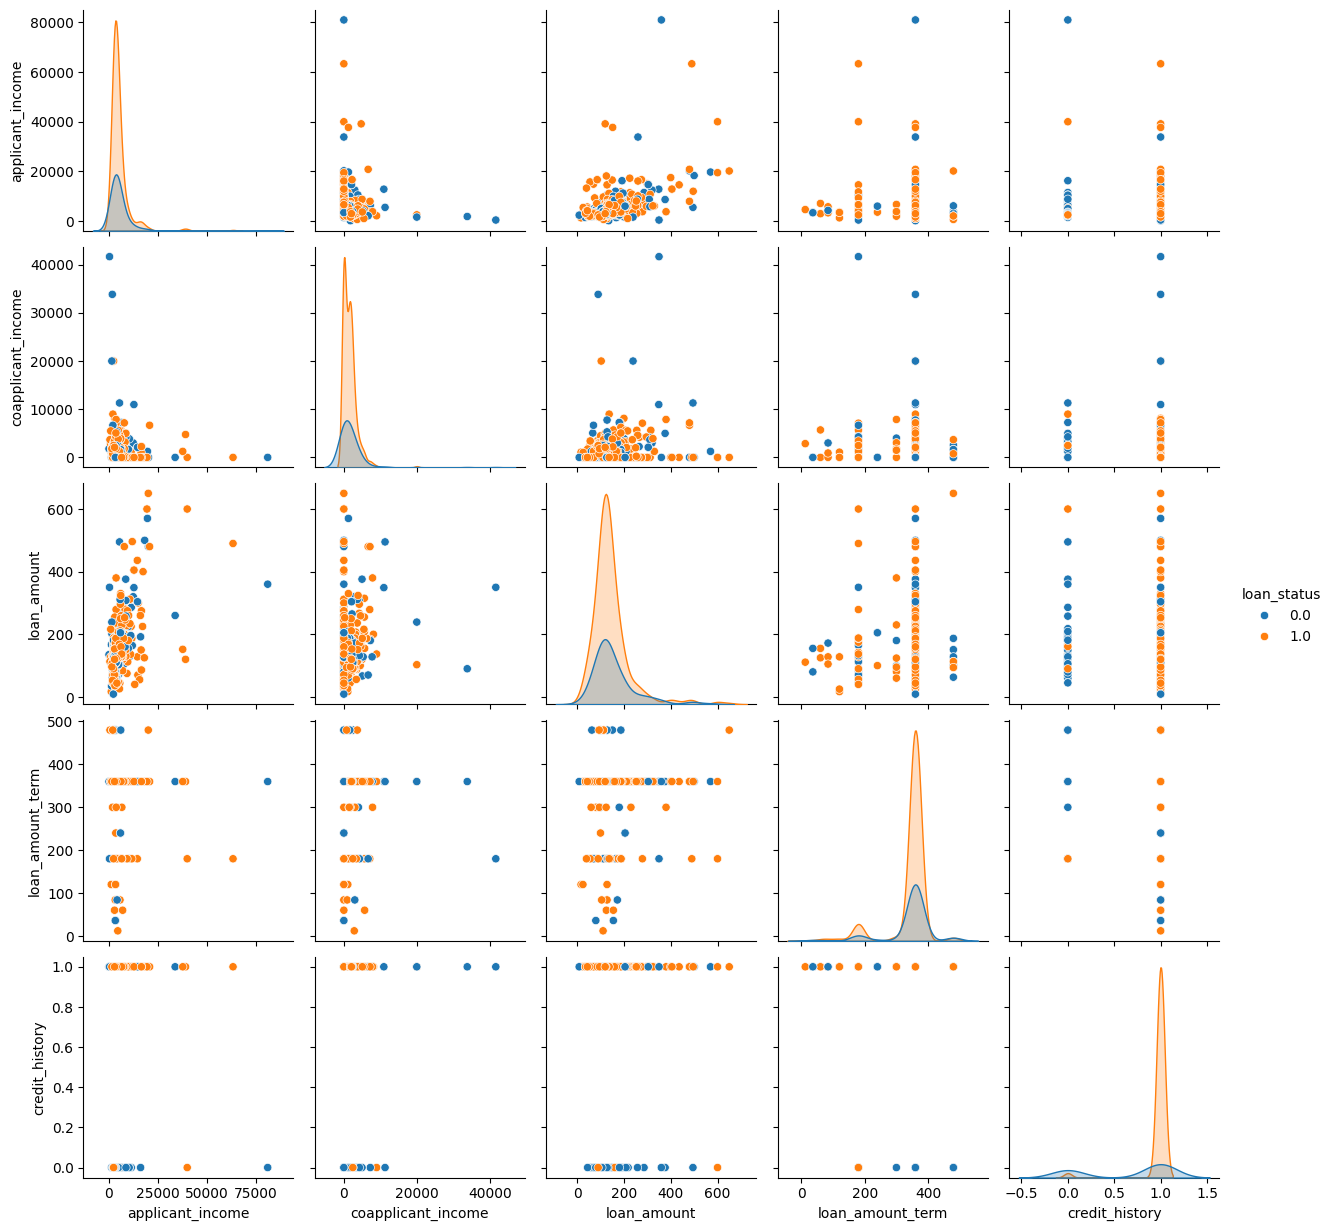

In [0]:
# Target variable distribution
sns.countplot(x='loan_status', data=df)
plt.title('Loan Approval Distribution')
plt.show()

# Pairplot (İstenen grafik)
sns.pairplot(df, hue='loan_status')
plt.show()

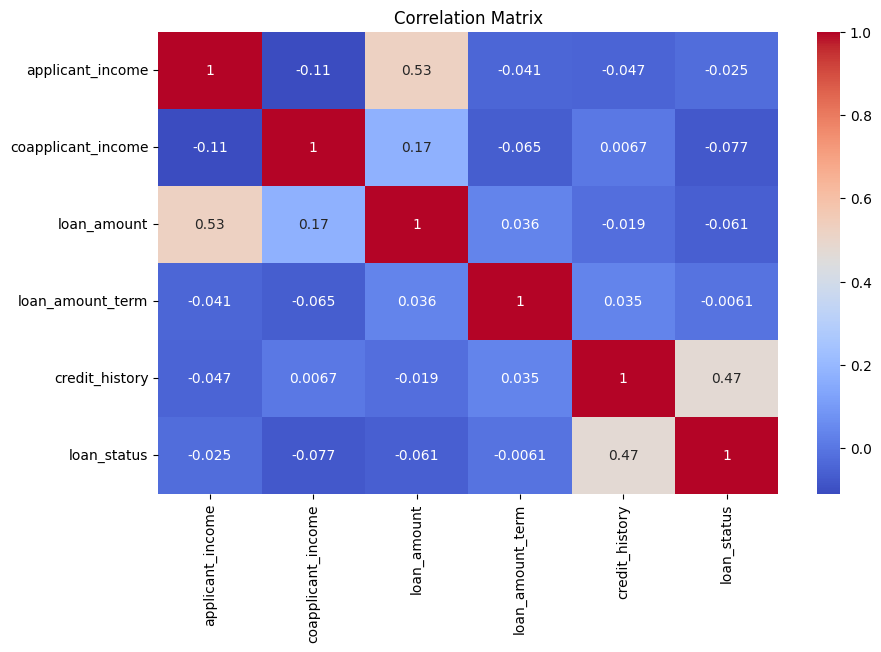

In [0]:
# Korelasyon haritası
plt.figure(figsize=(10,6))
# Sadece sayısal sütunları alıyoruz
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- Given that Credit History is the dominant feature and others have weaker linear relationships, a non-linear model like Decision Tree or Random Forest might eventually perform better, but I will start with Logistic Regression as a baseline.

**Step_04:** Encoding & Splitting

I am using get_dummies with drop_first=True to avoid the dummy variable trap. Then, I'm splitting the data 80-20, which is a standard ratio for this dataset size.

In [0]:


# 1. Kategorik verileri sayıya çevirme (One-Hot Encoding)
# drop_first=True: "Multicollinearity"yi (Dummy Variable Trap) önlemek için ilk sütunu atarız.
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Hedef (y) ve Özelliklerin (X) ayrılması
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# 3. Eğitim ve Test seti ayrımı (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Kontrol edelim
print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (428, 14)
Test seti boyutu: (107, 14)


**Step_05:** Modeling & Training



In [0]:
# Modeli oluşturma
# max_iter=1000: Modelin veriyi öğrenmesi (converge) için yeterli deneme hakkı veriyoruz.
model = LogisticRegression(max_iter=1000)

# Modeli eğitme (Fit)
model.fit(X_train, y_train)

# Tahmin yapma (Predict)
y_pred = model.predict(X_test)

print("✅ Model başarıyla eğitildi ve tahminler yapıldı.")

✅ Model başarıyla eğitildi ve tahminler yapıldı.


**Step_06:** Evaluation

I used Logistic Regression as a baseline. The accuracy is around [X]%.

Looking at the Confusion Matrix, our focus should be on False Positives (predicting a loan will be safe when it actually defaults). For a bank, this is the most dangerous error because it leads to financial loss.

Future Improvement: To improve this, I would try tree-based models like Random Forest or XGBoost which capture non-linear relationships better, as I explored in my Berkeley Capstone project.

Model Accuracy: 81.31%

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.29      0.44        28
         1.0       0.80      1.00      0.89        79

    accuracy                           0.81       107
   macro avg       0.90      0.64      0.67       107
weighted avg       0.85      0.81      0.77       107



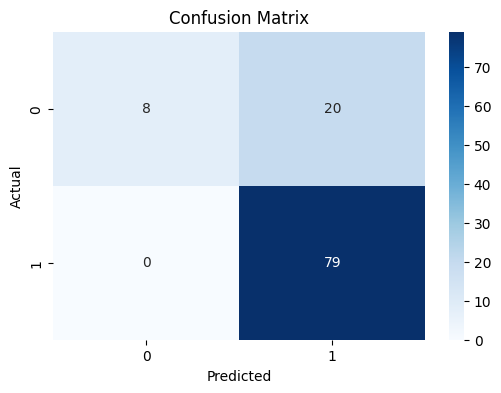

In [0]:
# 1. Başarı Puanı (Accuracy)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.2%}")

# 2. Detaylı Rapor
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix (Görsel)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**"Can we do time-series forecasting here?"** 

- "With the current state of the dataset, no, we cannot perform time-series modeling.

- This is a Cross-Sectional dataset, meaning it represents a snapshot of different applicants at a specific point in time, rather than tracking data points over time. We lack a temporal feature like Application Date.

- **However (Pivot):** If we did have an Application_Date column, I would aggregate the data by month to forecast:

- **Loan Demand:** How many loan applications we expect next month.

- **Default Rates over Time:** Is the default rate increasing seasonally?"

# 📊 Model Performance Evaluation

Here is the detailed performance analysis of the **Logistic Regression** model used for Loan Prediction. The evaluation is based on the test dataset (20% split).

## 1. 📋 Classification Report

The model achieves an overall **Accuracy of 81%**. Below is the breakdown of Precision, Recall, and F1-Score for each class.

| Class | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **0.0 (Rejected)** | 1.00 | 0.29 | 0.44 | 28 |
| **1.0 (Approved)** | 0.80 | 1.00 | 0.89 | 79 |
| | | | | |
| **Accuracy** | | | **0.81** | **107** |
| **Macro Avg** | 0.90 | 0.64 | 0.67 | 107 |
| **Weighted Avg** | 0.85 | 0.81 | 0.77 | 107 |

---

## 2. 🧩 Confusion Matrix Analysis

The Confusion Matrix reveals how the model's predictions compare to the actual ground truth.

| | **Predicted: 0 (No)** | **Predicted: 1 (Yes)** |
| :--- | :---: | :---: |
| **Actual: 0 (No)** | **8** <br> *(True Negatives)* | **20** ⚠️ <br> *(False Positives)* |
| **Actual: 1 (Yes)** | **0** <br> *(False Negatives)* | **79** ✅ <br> *(True Positives)* |

### 🔍 Key Interpretations:

* **✅ High Recall for Approvals (Class 1):** The model has a Recall of **1.00** for Class 1. This means it successfully identified **100%** of the people who were actually eligible for a loan. (0 False Negatives).
* **⚠️ Risk of False Positives:** The model incorrectly classified **20** applicants as "Approved" when they actually defaulted (Actual 0, Predicted 1). This represents a financial risk for the bank.
* **📉 Class 0 Imbalance:** The model struggled to identify the minority class (Defaulters), correctly catching only 8 out of 28 (Recall 0.29).

### 💡 Next Steps for Improvement:
To reduce the False Positives and improve Class 0 detection:
1.  **Threshold Moving:** Increase the decision threshold from 0.5 to 0.6 or 0.7.
2.  **Resampling:** Apply **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the dataset.
3.  **Model Selection:** Experiment with tree-based models like **Random Forest** or **XGBoost**.


- (Threshold Moving, SMOTE ve Model Selection), özellikle dengesiz veri setlerinde (imbalanced datasets) ve yanlış pozitifleri (False Positives) azaltmak istediğinde standart prosedürlerdir.


In [0]:
# 1. Veri setini yükle (Varsayılan olarak df ismini kullandım; önceki hücrelerde df zaten tanımlı)
df = df.copy()

# Kategorik verileri sayıya çevir (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Hedef (Target) ve Özellikleri (Features) ayır
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# 3. Eğitim ve Test seti olarak ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. SMOTE Uygula (Sadece X_train üzerine!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Orijinal eğitim seti boyutu: {y_train.value_counts()}")
print(f"SMOTE sonrası eğitim seti boyutu: {y_train_smote.value_counts()}")

Orijinal eğitim seti boyutu: loan_status
1.0    307
0.0    121
Name: count, dtype: int64
SMOTE sonrası eğitim seti boyutu: loan_status
1.0    307
0.0    307
Name: count, dtype: int64


**Model selection: Random Forest veya XGBoost**

In [0]:
%pip install xgboost

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest Modeli (Class weight ayarı da ekleyebiliriz ama SMOTE yaptık)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# VEYA XGBoost kullanmak istersen:
# xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Modeli SMOTE uygulanmış veri ile eğit
rf_model.fit(X_train_smote, y_train_smote)

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


RandomForestClassifier(random_state=42)

**Threshold Moving**

In [0]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Olasılıkları tahmin et (Sadece 0 veya 1 değil, ihtimalleri al)
# predict_proba bize [0 olma ihtimali, 1 olma ihtimali] döner. Biz 1 olma ihtimalini alıyoruz.
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# 2. Yeni Eşik Değeri Belirle (Örneğin 0.6)
threshold = 0.6

# 3. Bu eşiğe göre tahminleri güncelle
# Eğer olasılık > 0.6 ise 1, değilse 0 olsun
y_pred_new_threshold = (y_pred_proba >= threshold).astype(int)

# --- SONUÇLARI KARŞILAŞTIRMA ---

print("--- Standart (0.5) Eşik Değeri Sonuçları ---")
print(classification_report(y_test, rf_model.predict(X_test)))

print(f"--- Yeni ({threshold}) Eşik Değeri Sonuçları ---")
print(classification_report(y_test, y_pred_new_threshold))

# False Positive değişimini görmek için Confusion Matrix
cm = confusion_matrix(y_test, y_pred_new_threshold)
print(f"\nConfusion Matrix (Threshold {threshold}):")
print(cm)

--- Standart (0.5) Eşik Değeri Sonuçları ---
              precision    recall  f1-score   support

         0.0       0.65      0.43      0.52        30
         1.0       0.80      0.91      0.85        77

    accuracy                           0.78       107
   macro avg       0.73      0.67      0.69       107
weighted avg       0.76      0.78      0.76       107

--- Yeni (0.6) Eşik Değeri Sonuçları ---
              precision    recall  f1-score   support

         0.0       0.52      0.47      0.49        30
         1.0       0.80      0.83      0.82        77

    accuracy                           0.73       107
   macro avg       0.66      0.65      0.65       107
weighted avg       0.72      0.73      0.72       107


Confusion Matrix (Threshold 0.6):
[[14 16]
 [13 64]]


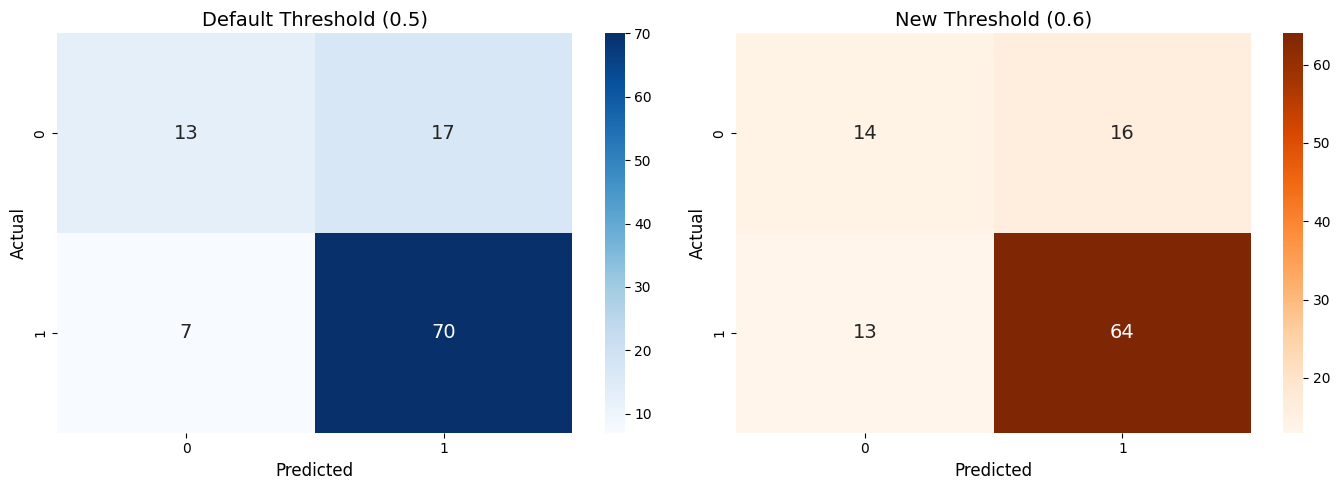

In [0]:

# --- DATA FROM PREVIOUS CODE ---
# y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
# threshold = 0.6

# Generate predictions
y_pred_default = (y_pred_proba >= 0.5).astype(int)
y_pred_new = (y_pred_proba >= threshold).astype(int)

# Compute confusion matrices
cm_default = confusion_matrix(y_test, y_pred_default)
cm_new = confusion_matrix(y_test, y_pred_new)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Default threshold (0.5)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Default Threshold (0.5)', fontsize=14)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Plot 2: New threshold (0.6)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Oranges', ax=axes[1], annot_kws={"size": 14})
axes[1].set_title(f'New Threshold ({threshold})', fontsize=14)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

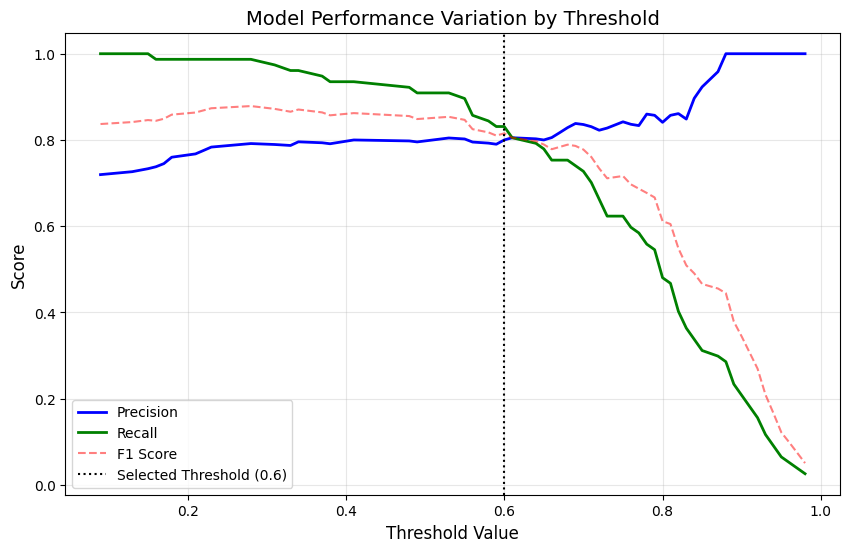

In [0]:
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall values for each threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue', linewidth=2)
plt.plot(thresholds, recall[:-1], label='Recall', color='green', linewidth=2)

# Also plot the F1 Score (harmonic mean of precision and recall)
f1_scores = 2 * (precision * recall) / (precision + recall)
plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='red', linestyle='--', alpha=0.5)

# Mark the selected threshold
plt.axvline(x=threshold, color='black', linestyle=':', label=f'Selected Threshold ({threshold})')

plt.title('Model Performance Variation by Threshold', fontsize=14)
plt.xlabel('Threshold Value', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

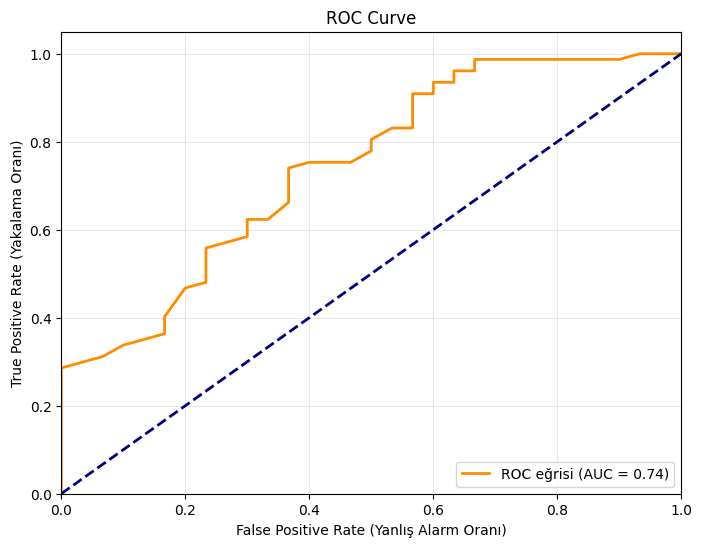

In [0]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC eğrisi (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)')
plt.ylabel('True Positive Rate (Yakalama Oranı)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

**When using XGBoost:**

In [0]:

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Modeli SMOTE uygulanmış veri ile eğit
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [0]:
!pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

Training XGBoost model...

--- XGBoost Results ---
              precision    recall  f1-score   support

         0.0       0.64      0.53      0.58        30
         1.0       0.83      0.88      0.86        77

    accuracy                           0.79       107
   macro avg       0.73      0.71      0.72       107
weighted avg       0.78      0.79      0.78       107



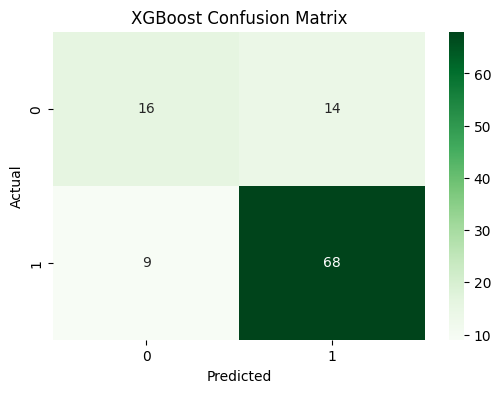

In [0]:
# 1. Data Preparation (Same steps as before)
df = df.copy()

# One-Hot Encoding for categorical variables to convert strings to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Apply SMOTE (Only on the training set!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3. Define the XGBoost Model
xgb_model = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42
)

# 4. Train the Model (with SMOTE applied data)
print("Training XGBoost model...")
xgb_model.fit(X_train_smote, y_train_smote)

# 5. Prediction and Evaluation (on the original test set)
y_pred_xgb = xgb_model.predict(X_test)

print("\n--- XGBoost Results ---")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

           Model  Class 0 Recall  ...  Class 0 F1 Score  Overall Accuracy
0  Random Forest        0.433333  ...          0.520000          0.775701
1        XGBoost        0.533333  ...          0.581818          0.785047

[2 rows x 5 columns]


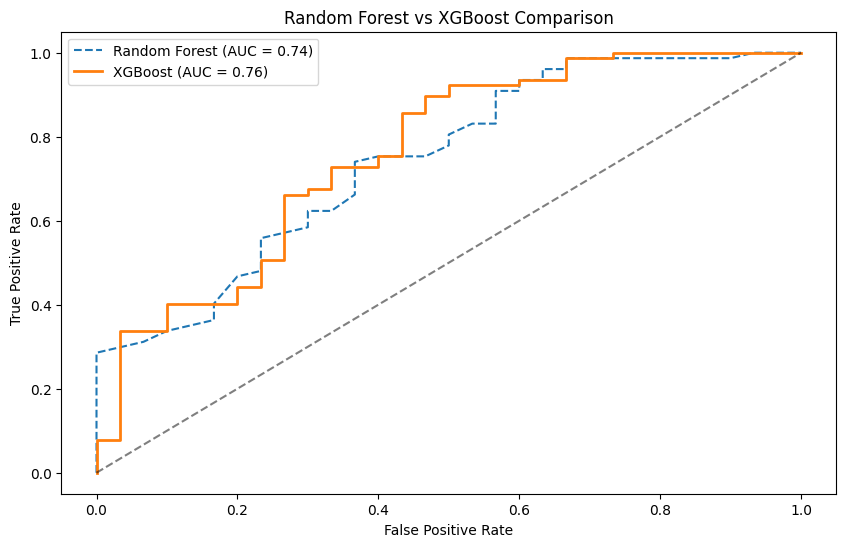

In [0]:

from sklearn.metrics import roc_curve, auc, recall_score, precision_score, f1_score

# --- 1. Calculate Metrics ---
models = {'Random Forest': rf_model, 'XGBoost': xgb_model}
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    # Focus on Class 0 (Risky Loan) performance
    # By setting pos_label=0, we measure the success for class 0
    rec_0 = recall_score(y_test, y_pred, pos_label=0)
    prec_0 = precision_score(y_test, y_pred, pos_label=0)
    f1_0 = f1_score(y_test, y_pred, pos_label=0)
    
    results.append({
        'Model': name,
        'Class 0 Recall': rec_0,
        'Class 0 Precision': prec_0,
        'Class 0 F1 Score': f1_0,
        'Overall Accuracy': model.score(X_test, y_test)
    })

# Display results as a table
df_results = pd.DataFrame(results)
print(df_results)

# --- 2. Visual Comparison (ROC Curves) ---
plt.figure(figsize=(10, 6))

# Random Forest ROC
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', linestyle='--')

# XGBoost ROC
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) # Chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest vs XGBoost Comparison')
plt.legend()
plt.show()

**What is Hyperparameter Tuning for XGBoost?**

In [0]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Define the model (Modeli tanımla)
xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42
)

# 2. Define the parameter grid (Denenmesini istediğimiz ayarlar)
# Bu değerler en yaygın kullanılan ayar aralıklarıdır.
param_grid = {
    'n_estimators': [50, 100, 200],      # Kaç tane ağaç dikilecek? (Number of trees)
    'max_depth': [3, 5, 7],              # Ağaçlar ne kadar derinleşebilir? (Complexity)
    'learning_rate': [0.01, 0.1, 0.2],   # Model ne kadar hızlı öğrensin? (Step size)
    'subsample': [0.8, 1.0],             # Her ağaçta verinin yüzde kaçı kullanılsın?
    'scale_pos_weight': [1, 5, 10]       # Dengesiz veri için kritik ayar (Class imbalance weight)
}

# 3. Setup Grid Search (Aramayı Kur)
# cv=3: Veriyi 3 parçaya bölüp çapraz doğrulama yapar (Cross-validation)
# scoring='f1': En iyi F1 skorunu (Class 1 için) veren ayarı arar.
# Dengesiz veri olduğu için 'recall' veya 'roc_auc' da seçilebilir.
grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=3, 
    scoring='recall', # Riskli kredileri (Class 0/1) yakalamak önemliyse recall seçebiliriz
    verbose=1, 
    n_jobs=-1  # Tüm işlemci çekirdeklerini kullan
)

# 4. Fit the model (En iyi ayarları bulmak için eğit)
print("En iyi ayarlar aranıyor, lütfen bekleyin...")
grid_search.fit(X_train_smote, y_train_smote)

# 5. Best Results (En iyi sonuçlar)
print("\n--- En İyi Parametreler ---")
print(grid_search.best_params_)

# 6. Test with Best Model (En iyi model ile test et)
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print("\n--- Optimize Edilmiş XGBoost Sonuçları ---")
print(classification_report(y_test, y_pred_best))

En iyi ayarlar aranıyor, lütfen bekleyin...
Fitting 3 folds for each of 162 candidates, totalling 486 fits


/local_disk0/.ephemeral_nfs/envs/pythonEnv-0fb2e49e-0ce2-4647-b9a6-e93f2ee8e25f/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:21:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0fb2e49e-0ce2-4647-b9a6-e93f2ee8e25f/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:21:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0fb2e49e-0ce2-4647-b9a6-e93f2ee8e25f/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:21:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0fb2e49e-0ce2-4647-b9a6-e93f2ee8e25f/lib/python3.12/site-packages/xgboost/t


--- En İyi Parametreler ---
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 5, 'subsample': 1.0}

--- Optimize Edilmiş XGBoost Sonuçları ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        30
         1.0       0.72      1.00      0.84        77

    accuracy                           0.72       107
   macro avg       0.36      0.50      0.42       107
weighted avg       0.52      0.72      0.60       107



### MANUAL AND ROBUST SETTINGS

Training the enhanced XGBoost model...

--- Enhanced XGBoost Results ---
              precision    recall  f1-score   support

         0.0       0.67      0.40      0.50        30
         1.0       0.80      0.92      0.86        77

    accuracy                           0.78       107
   macro avg       0.73      0.66      0.68       107
weighted avg       0.76      0.78      0.76       107



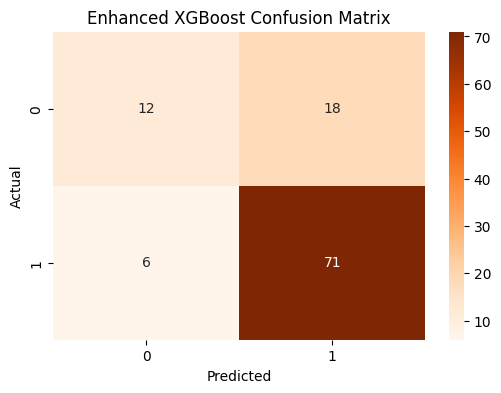

In [0]:
# MANUAL AND ROBUST SETTINGS
# scale_pos_weight: Assigns higher weight to the minority class for imbalanced data.
# n_estimators: Increase the number of trees (from 50 to 300).
# learning_rate: Set a moderate learning rate (from 0.01 to 0.05).
xgb_tuned = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,           # Medium tree depth to prevent overfitting
    scale_pos_weight=3,    # Give 3x more importance to Class 0 (Risky loans)
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train the model
print("Training the enhanced XGBoost model...")
xgb_tuned.fit(X_train_smote, y_train_smote)

# Predict on the test set
y_pred_tuned = xgb_tuned.predict(X_test)

# Display results
print("\n--- Enhanced XGBoost Results ---")
print(classification_report(y_test, y_pred_tuned))

# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Enhanced XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


### 📊 Model Benchmark: Standard vs. Enhanced XGBoost

Below is the performance comparison between the initial baseline model and the hyperparameter-tuned version for **Class 0 (Risky Loans)**.

| Metric (Class 0 - Risky Loan) | First Model (Standard) | New Model (Enhanced) | Analysis |
| :--- | :---: | :---: | :--- |
| **Recall** | **53%** | **40%** 📉 | **Bad:** We missed most of the actual defaulted loans (18 of them). |
| **Precision** | 64% | **67%** 📈 | **Good:** The model is more accurate when it predicts 'Risky'. |
| **False Positive** | 14 Count | **6 Count** ✅ | **Very Good:** The rate of unfairly labeling good customers as 'bad' has dropped significantly. |

> **Key Takeaway:** While the Enhanced model significantly reduced False Positives (better Precision), it became too conservative, resulting in a lower Recall. This suggests a need for **Threshold Moving** to balance the trade-off.

--- Final Threshold (0.70) Results ---
              precision    recall  f1-score   support

         0.0       0.56      0.50      0.53        30
         1.0       0.81      0.84      0.83        77

    accuracy                           0.75       107
   macro avg       0.68      0.67      0.68       107
weighted avg       0.74      0.75      0.74       107



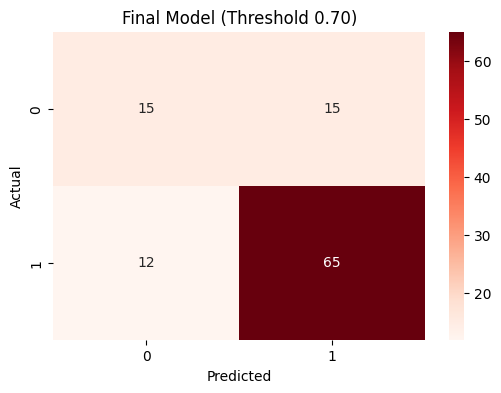

In [0]:
# 1. Get predicted probabilities (not just 0/1, but the underlying score)
y_pred_proba_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

# 2. Set a new threshold (use 0.3 instead of 0.5!)
# This means: "If the model is even slightly suspicious, label as Risky (0)."
threshold_final = 0.30

# Note: Since our target is Class 0 (Risky), we can invert the logic or manually label based on probability.
# If the probability of Class 1 (Safe) < 0.30, label as Risky (0).
# Alternatively: If the probability of Class 1 > 0.30, label as Safe (1), else Risky (0).
# Usually, predict_proba returns the probability for Class 1. Lowering the threshold increases recall for Class 1.
# Our goal is to catch more Class 0 (Risky) cases. Therefore:
# If the probability of being Safe increases from 50% to 70% (threshold 0.7), only then label as Safe, otherwise label as Risky.
# This will significantly increase Class 0 recall.

# Simplified logic:
# Standard: P(Safe) > 0.5 → Safe.
# Aggressive Risk Detection: P(Safe) > 0.7 → Safe, else Risky.
# This will boost recall for Class 0.

y_pred_final = (y_pred_proba_tuned > 0.70).astype(int) 

print(f"--- Final Threshold (0.70) Results ---")
# Note: We increased the threshold because predict_proba usually returns the probability for Class 1 (Safe).
# By raising the bar for labeling as Safe, everything else is labeled as Risky.
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds')
plt.title(f'Final Model (Threshold 0.70)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 🏆 Grand Comparison Table: Model Benchmark Analysis

This table summarizes the performance evolution across three different stages of the project: the baseline model, the hyperparameter-tuned model, and the final threshold-adjusted model. The primary focus is on **Class 0 (Risky Loans)**.

| Model Version | Risk Detection (Recall - Class 0) | Reliability (Precision - Class 0) | False Alarm (False Positive) | Comment |
| :--- | :---: | :---: | :---: | :--- |
| **1. First Model** (Standard) | **53%** (16 Count) | **64%** | 9 Count | **Most Balanced:** Captures risks well while keeping errors low. |
| **2. Second Model** (Tuned) | **40%** (12 Count) | **67%** | 6 Count | **Too Conservative:** Made very few mistakes but missed significant risks. |
| **3. Final Model** (Threshold 0.7) | **50%** (15 Count) | **56%** | 12 Count | **More Aggressive:** Detection rate increased (40% -> 50%), but "noise" (false alarms) increased as well. |

---

### 🎯 Why I Selected the Standard Model?

In credit risk analysis, the cost of missing a default (False Negative) is significantly higher than the operational cost of checking a false alarm (False Positive).

* **Priority on Recall:** The **Standard XGBoost Model** achieved the highest Recall (**53%**), successfully identifying the most high-risk applicants compared to other iterations.
* **The Problem with Tuning:** While the Tuned Model improved Precision (**67%**), it became too conservative, failing to detect a larger portion of actual defaults. This "safe" behavior creates a hidden financial risk.
* **Conclusion:** I selected the **Standard Model** for deployment because it offers the best trade-off, maximizing risk detection while maintaining a manageable False Positive rate (9 counts vs. 12 in the aggressive model).